In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content

!cp /content/drive/MyDrive/MPNet-master.zip .
!unzip -oq MPNet-master.zip

!cp /content/drive/MyDrive/dataset.zip .
!unzip -oq dataset.zip

%cd /content/MPNet-master/MPNet

!sed -i 's/print \"epoch\" + str(epoch)/print(\"epoch\" + str(epoch))/g' AE/CAE.py
!sed -i 's/print \"--average loss:\"/print(\"--average loss:\")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(len(obs)\/args.batch_size)/print(avg_loss\/(len(obs)\/args.batch_size))/g' AE/CAE.py
!sed -i 's/print "--Validation average loss:"/print("--Validation average loss:")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(5000\/args.batch_size)/print(avg_loss\/(5000\/args.batch_size))/g' AE/CAE.py

!grep -n "print " AE/CAE.py

import os
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from AE.CAE import Encoder
from model import MLP


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

encoder = Encoder().to(device)

encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/cae_encoder.pkl",
        map_location=device
    )
)

encoder.eval()
print("Encoder loaded")

pnet = MLP(32, 2).to(device)

pnet.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl",
        map_location=device
    )
)

pnet.eval()
print("MPNet loaded")


DATASET_DIR = "/content/dataset"

obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc1.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

print("obs_code shape:", obs_code.shape)

Mounted at /content/drive
/content
/content/MPNet-master/MPNet
cuda
Encoder loaded
MPNet loaded
obs_code shape: torch.Size([28])


In [5]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

DATASET_DIR = "/content/dataset"

GOAL_THRESHOLD = 0.10
COLLISION_THRESHOLD = 0.03


def sorted_case_ids(env_id):
    folder = f"{DATASET_DIR}/e{env_id}"
    files = [
        f for f in os.listdir(folder)
        if re.match(r"path\d+\.dat$", f)
    ]
    return sorted(int(re.findall(r"\d+", f)[0]) for f in files)


def load_obs_xy(env_id):
    obs_file = f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat"
    obs = np.fromfile(obs_file)
    return obs.reshape(-1, 2).astype(np.float32)


def load_expert_path(env_id, case_id):
    path_file = f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
    path = np.fromfile(path_file)
    return path.reshape(-1, 2).astype(np.float32)


def get_obs_code(obs_xy):
    obs_flat = obs_xy.reshape(-1)
    obs_input = torch.from_numpy(obs_flat).float().unsqueeze(0).to(device)

    with torch.no_grad():
        return encoder(obs_input).squeeze(0)


def path_length_np(path):
    path = np.asarray(path, dtype=np.float32)
    if len(path) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1)))


In [6]:
def point_to_segment_distance(points, a, b):
    points = np.asarray(points, dtype=np.float32)
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    ab = b - a
    ab_norm_sq = np.dot(ab, ab)

    if ab_norm_sq < 1e-8:
        return np.linalg.norm(points - a, axis=1)

    t = np.dot(points - a, ab) / ab_norm_sq
    t = np.clip(t, 0.0, 1.0)

    projection = a + t[:, None] * ab
    return np.linalg.norm(points - projection, axis=1)


def obstacle_density_near_line(start, goal, obs_xy, threshold=0.05):
    dists = point_to_segment_distance(obs_xy, start, goal)
    return float(np.mean(dists < threshold))


def straight_line_collision(start, goal, obs_xy, threshold=0.03, samples=60):
    start = np.asarray(start, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    for i in range(samples + 1):
        t = i / samples
        p = (1.0 - t) * start + t * goal

        if np.min(np.linalg.norm(obs_xy - p, axis=1)) < threshold:
            return True

    return False


def build_high_difficulty_cases(
    top_k=100,
    env_ids=range(1, 20),
    cases_per_env=300,
    min_detour_ratio=1.10,
    min_density=0.02
):
    candidates = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        ids = sorted_case_ids(env_id)[:cases_per_env]

        for case_id in ids:
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            start = expert_path[0]
            goal = expert_path[-1]

            straight_len = float(np.linalg.norm(goal - start))
            expert_len = path_length_np(expert_path)

            if straight_len < 1e-6:
                continue

            detour_ratio = expert_len / straight_len

            has_straight_collision = straight_line_collision(
                start,
                goal,
                obs_xy,
                threshold=COLLISION_THRESHOLD,
                samples=60
            )

            density = obstacle_density_near_line(
                start,
                goal,
                obs_xy,
                threshold=0.05
            )

            if has_straight_collision and detour_ratio >= min_detour_ratio and density >= min_density:
                difficulty_score = detour_ratio + 5.0 * density

                candidates.append({
                    "env_id": env_id,
                    "case_id": case_id,
                    "start": start,
                    "goal": goal,
                    "obs_xy": obs_xy,
                    "obs_code": obs_code,
                    "expert_path": expert_path,
                    "straight_len": straight_len,
                    "expert_len": expert_len,
                    "detour_ratio": detour_ratio,
                    "obstacle_density": density,
                    "difficulty_score": difficulty_score,
                })

    candidates = sorted(
        candidates,
        key=lambda c: c["difficulty_score"],
        reverse=True
    )

    return candidates[:top_k], candidates


high_difficulty_cases, all_difficulty_candidates = build_high_difficulty_cases(
    top_k=100,
    env_ids=range(1, 20),
    cases_per_env=300,
    min_detour_ratio=1.10,
    min_density=0.02
)

print("all candidates:", len(all_difficulty_candidates))
print("selected high difficulty cases:", len(high_difficulty_cases))

for c in high_difficulty_cases[:10]:
    print(
        "env", c["env_id"],
        "case", c["case_id"],
        "score", round(c["difficulty_score"], 3),
        "detour", round(c["detour_ratio"], 3),
        "density", round(c["obstacle_density"], 3)
    )


all candidates: 2232
selected high difficulty cases: 100
env 15 case 16 score 17.42 detour 16.863 density 0.111
env 17 case 41 score 14.592 detour 14.245 density 0.069
env 17 case 205 score 10.868 detour 10.468 density 0.08
env 5 case 139 score 10.083 detour 9.926 density 0.031
env 18 case 49 score 7.933 detour 7.75 density 0.036
env 13 case 253 score 7.618 detour 7.125 density 0.099
env 1 case 99 score 6.736 detour 6.168 density 0.114
env 18 case 150 score 6.228 detour 5.974 density 0.051
env 12 case 233 score 6.188 detour 5.781 density 0.081
env 14 case 118 score 6.091 detour 5.97 density 0.024


In [7]:
def build_high_difficulty_cases(
    top_k=100,
    env_ids=range(1, 20),
    cases_per_env=300,
    min_detour_ratio=1.10,
    max_detour_ratio=5.0,
    min_straight_len=0.25,
    min_density=0.02
):
    candidates = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        ids = sorted_case_ids(env_id)[:cases_per_env]

        for case_id in ids:
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            start = expert_path[0]
            goal = expert_path[-1]

            straight_len = float(np.linalg.norm(goal - start))
            expert_len = path_length_np(expert_path)

            if straight_len < min_straight_len:
                continue

            detour_ratio = expert_len / straight_len

            if detour_ratio > max_detour_ratio:
                continue

            has_straight_collision = straight_line_collision(
                start,
                goal,
                obs_xy,
                threshold=COLLISION_THRESHOLD,
                samples=60
            )

            density = obstacle_density_near_line(
                start,
                goal,
                obs_xy,
                threshold=0.05
            )

            if has_straight_collision and detour_ratio >= min_detour_ratio and density >= min_density:
                difficulty_score = detour_ratio + 5.0 * density

                candidates.append({
                    "env_id": env_id,
                    "case_id": case_id,
                    "start": start,
                    "goal": goal,
                    "obs_xy": obs_xy,
                    "obs_code": obs_code,
                    "expert_path": expert_path,
                    "straight_len": straight_len,
                    "expert_len": expert_len,
                    "detour_ratio": detour_ratio,
                    "obstacle_density": density,
                    "difficulty_score": difficulty_score,
                })

    candidates = sorted(
        candidates,
        key=lambda c: c["difficulty_score"],
        reverse=True
    )

    return candidates[:top_k], candidates


In [8]:
high_difficulty_cases, all_difficulty_candidates = build_high_difficulty_cases(
    top_k=100,
    env_ids=range(1, 20),
    cases_per_env=300,
    min_detour_ratio=1.10,
    max_detour_ratio=5.0,
    min_straight_len=0.25,
    min_density=0.02
)

print("all candidates:", len(all_difficulty_candidates))
print("selected high difficulty cases:", len(high_difficulty_cases))

for c in high_difficulty_cases[:10]:
    print(
        "env", c["env_id"],
        "case", c["case_id"],
        "score", round(c["difficulty_score"], 3),
        "detour", round(c["detour_ratio"], 3),
        "density", round(c["obstacle_density"], 3),
        "straight", round(c["straight_len"], 3)
    )


all candidates: 2172
selected high difficulty cases: 100
env 12 case 192 score 5.833 detour 4.565 density 0.254 straight 0.28
env 2 case 7 score 5.59 detour 4.265 density 0.265 straight 0.273
env 11 case 183 score 5.518 detour 4.768 density 0.15 straight 0.302
env 12 case 3 score 5.478 detour 4.442 density 0.207 straight 0.286
env 12 case 191 score 5.419 detour 4.672 density 0.149 straight 0.385
env 3 case 112 score 5.293 detour 4.643 density 0.13 straight 0.259
env 19 case 213 score 5.256 detour 4.267 density 0.198 straight 0.38
env 16 case 266 score 5.166 detour 3.749 density 0.284 straight 0.385
env 18 case 138 score 5.137 detour 4.572 density 0.113 straight 0.354
env 15 case 32 score 5.065 detour 2.876 density 0.438 straight 0.416


In [11]:
def generate_fast_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )


def generate_goal_biased_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.5,
        max_steps=150
    )


def generate_hybrid_for_exp6(start, goal, obs_code, obs_xy):
    path, info = generate_hybrid_mpnet_path_v3(
        start=start,
        goal=goal,
        obs_code=obs_code,
        obs_xy=obs_xy,
        max_iter=600
    )
    return path


def generate_rrt_path(start, goal, obs_xy):
    path, success = rrt_repair(
        start=start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=3000,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if success:
        return path

    return np.asarray([start, goal], dtype=np.float32)


def evaluate_method_on_cases(cases, method_name):
    metrics_all = []

    for case in cases:
        start = case["start"]
        goal = case["goal"]
        obs_xy = case["obs_xy"]
        obs_code = case["obs_code"]
        expert_path = case["expert_path"]

        t0 = time.time()

        if method_name == "Fast MPNet":
            path = generate_fast_mpnet_path(start, goal, obs_code)

        elif method_name == "Goal-biased MPNet":
            path = generate_goal_biased_mpnet_path(start, goal, obs_code)

        elif method_name == "Hybrid MPNet":
            path = generate_hybrid_for_exp6(start, goal, obs_code, obs_xy)

        elif method_name == "RRT":
            path = generate_rrt_path(start, goal, obs_xy)

        else:
            raise ValueError(method_name)

        elapsed = time.time() - t0

        metrics = evaluate_path(path, goal, obs_xy, expert_path)
        metrics["time"] = elapsed
        metrics_all.append(metrics)

    return {
        "method": method_name,
        "total": len(cases),
        "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
        "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
        "avg_time": float(np.mean([m["time"] for m in metrics_all])),
        "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
        "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
        "avg_ratio": float(np.nanmean([m["ratio"] for m in metrics_all])),
    }


def evaluate_methods_on_high_difficulty(cases):
    methods = [
        "Fast MPNet",
        "Goal-biased MPNet",
        "Hybrid MPNet",
        "RRT"
    ]

    rows = []

    for method in methods:
        row = evaluate_method_on_cases(cases, method)
        row["split"] = "High-Difficulty Subset"
        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


In [13]:
import time
import random
import numpy as np
import pandas as pd
import torch

GOAL_THRESHOLD = 0.10
COLLISION_THRESHOLD = 0.03


def generate_goal_bias_path(start, goal, obs_code, alpha=0.0, max_steps=150):
    current = torch.from_numpy(np.asarray(start, dtype=np.float32)).float().to(device)
    goal_t = torch.from_numpy(np.asarray(goal, dtype=np.float32)).float().to(device)

    if not isinstance(obs_code, torch.Tensor):
        obs_code = torch.from_numpy(np.asarray(obs_code, dtype=np.float32)).float().to(device)
    else:
        obs_code = obs_code.float().to(device)

    obs_code = obs_code.view(-1)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            # Correct input order:
            # obs_code + goal + current = 28 + 2 + 2 = 32
            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)

            pred = pnet(inp).squeeze(0)
            next_state = (1.0 - alpha) * pred + alpha * goal_t

            path.append(next_state.detach().cpu().numpy())
            current = next_state

            if torch.norm(current - goal_t).item() <= GOAL_THRESHOLD:
                break

    return np.asarray(path, dtype=np.float32)


def path_length_np(path):
    path = np.asarray(path, dtype=np.float32)
    if len(path) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1)))


def path_in_collision(path, obs_xy, threshold=0.03, samples_per_segment=20):
    path = np.asarray(path, dtype=np.float32)
    obs_xy = np.asarray(obs_xy, dtype=np.float32).reshape(-1, 2)

    if len(path) < 2:
        return False

    for i in range(len(path) - 1):
        a = path[i]
        b = path[i + 1]

        for s in range(samples_per_segment + 1):
            t = s / samples_per_segment
            p = (1.0 - t) * a + t * b

            d = np.linalg.norm(obs_xy - p, axis=1)
            if np.min(d) < threshold:
                return True

    return False


def evaluate_path(path, goal, obs_xy, expert_path=None):
    path = np.asarray(path, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    if len(path) == 0:
        return {
            "success": False,
            "collision": True,
            "final_dist": float("inf"),
            "path_length": float("inf"),
            "ratio": np.nan,
        }

    final_dist = float(np.linalg.norm(path[-1] - goal))
    collision = path_in_collision(
        path,
        obs_xy,
        threshold=COLLISION_THRESHOLD,
        samples_per_segment=20
    )

    length = path_length_np(path)
    success = (final_dist <= GOAL_THRESHOLD) and (not collision)

    ratio = np.nan
    if expert_path is not None:
        expert_len = path_length_np(expert_path)
        if expert_len > 1e-8:
            ratio = length / expert_len

    return {
        "success": success,
        "collision": collision,
        "final_dist": final_dist,
        "path_length": length,
        "ratio": ratio,
    }


def steer(from_state, to_state, step_size=0.04):
    from_state = np.asarray(from_state, dtype=np.float32)
    to_state = np.asarray(to_state, dtype=np.float32)

    direction = to_state - from_state
    dist = np.linalg.norm(direction)

    if dist <= step_size:
        return to_state

    return from_state + step_size * direction / (dist + 1e-8)


def edge_in_collision(a, b, obs_xy, threshold=0.03, samples=20):
    return path_in_collision(
        np.asarray([a, b], dtype=np.float32),
        obs_xy,
        threshold=threshold,
        samples_per_segment=samples
    )


def rrt_repair(start, goal, obs_xy, max_iter=3000, step_size=0.04, goal_sample_rate=0.20):
    start = np.asarray(start, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    nodes = [start]
    parents = [-1]

    for _ in range(max_iter):
        if random.random() < goal_sample_rate:
            sample = goal
        else:
            sample = np.random.uniform(0.0, 1.0, size=2).astype(np.float32)

        nearest_idx = int(np.argmin([np.linalg.norm(n - sample) for n in nodes]))
        nearest = nodes[nearest_idx]

        new_node = steer(nearest, sample, step_size=step_size)

        if edge_in_collision(nearest, new_node, obs_xy):
            continue

        nodes.append(new_node)
        parents.append(nearest_idx)

        if np.linalg.norm(new_node - goal) <= GOAL_THRESHOLD:
            if not edge_in_collision(new_node, goal, obs_xy):
                nodes.append(goal)
                parents.append(len(nodes) - 2)

                path = []
                idx = len(nodes) - 1

                while idx != -1:
                    path.append(nodes[idx])
                    idx = parents[idx]

                return np.asarray(path[::-1], dtype=np.float32), True

    return np.asarray([start, goal], dtype=np.float32), False


def first_collision_prefix(path, obs_xy):
    path = np.asarray(path, dtype=np.float32)

    if len(path) <= 1:
        return path

    safe = [path[0]]

    for i in range(1, len(path)):
        if edge_in_collision(path[i - 1], path[i], obs_xy):
            break
        safe.append(path[i])

    return np.asarray(safe, dtype=np.float32)


def generate_hybrid_mpnet_path_v3(start, goal, obs_code, obs_xy, max_iter=600):
    coarse_path = generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )

    safe_prefix = first_collision_prefix(coarse_path, obs_xy)
    repair_start = safe_prefix[-1]

    repair_path, repair_success = rrt_repair(
        start=repair_start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=max_iter,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if repair_success and len(repair_path) > 1:
        full_path = np.vstack([safe_prefix, repair_path[1:]])
    else:
        full_path = coarse_path

    return full_path, {
        "repair_success": repair_success,
        "safe_prefix_len": len(safe_prefix),
    }


def generate_fast_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )


def generate_goal_biased_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.5,
        max_steps=150
    )


def generate_hybrid_for_exp6(start, goal, obs_code, obs_xy):
    path, info = generate_hybrid_mpnet_path_v3(
        start=start,
        goal=goal,
        obs_code=obs_code,
        obs_xy=obs_xy,
        max_iter=600
    )
    return path


def generate_rrt_path(start, goal, obs_xy):
    path, success = rrt_repair(
        start=start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=3000,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if success:
        return path

    return np.asarray([start, goal], dtype=np.float32)


def evaluate_method_on_cases(cases, method_name):
    metrics_all = []

    for case in cases:
        start = case["start"]
        goal = case["goal"]
        obs_xy = case["obs_xy"]
        obs_code = case["obs_code"]
        expert_path = case["expert_path"]

        t0 = time.time()

        if method_name == "Fast MPNet":
            path = generate_fast_mpnet_path(start, goal, obs_code)

        elif method_name == "Goal-biased MPNet":
            path = generate_goal_biased_mpnet_path(start, goal, obs_code)

        elif method_name == "Hybrid MPNet":
            path = generate_hybrid_for_exp6(start, goal, obs_code, obs_xy)

        elif method_name == "RRT":
            path = generate_rrt_path(start, goal, obs_xy)

        else:
            raise ValueError(method_name)

        elapsed = time.time() - t0

        metrics = evaluate_path(path, goal, obs_xy, expert_path)
        metrics["time"] = elapsed
        metrics_all.append(metrics)

    return {
        "method": method_name,
        "total": len(cases),
        "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
        "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
        "avg_time": float(np.mean([m["time"] for m in metrics_all])),
        "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
        "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
        "avg_ratio": float(np.nanmean([m["ratio"] for m in metrics_all])),
    }


def evaluate_methods_on_high_difficulty(cases):
    methods = [
        "Fast MPNet",
        "Goal-biased MPNet",
        "Hybrid MPNet",
        "RRT"
    ]

    rows = []

    for method in methods:
        row = evaluate_method_on_cases(cases, method)
        row["split"] = "High-Difficulty Subset"
        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


In [14]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

experiment6_df = evaluate_methods_on_high_difficulty(high_difficulty_cases)

display(experiment6_df)

experiment6_df.to_csv(
    "/content/drive/MyDrive/experiment6_high_difficulty_results.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/experiment6_high_difficulty_results.csv")


{'method': 'Fast MPNet', 'total': 100, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.005429272651672363, 'avg_path_length': 0.4258843119442463, 'avg_final_dist': 0.05509034910239279, 'avg_ratio': 0.3081710742381873, 'split': 'High-Difficulty Subset'}
{'method': 'Goal-biased MPNet', 'total': 100, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0013759255409240723, 'avg_path_length': 0.4468804310262203, 'avg_final_dist': 0.02798256802605465, 'avg_ratio': 0.3238130521736842, 'split': 'High-Difficulty Subset'}
{'method': 'Hybrid MPNet', 'total': 100, 'success_rate': np.float64(60.0), 'collision_rate': np.float64(40.0), 'avg_time': 0.3211918520927429, 'avg_path_length': 0.6610739989578724, 'avg_final_dist': 0.02238741923123598, 'avg_ratio': 0.47884911922716566, 'split': 'High-Difficulty Subset'}
{'method': 'RRT', 'total': 100, 'success_rate': np.float64(62.0), 'collision_rate': np.float64(38.0), 'avg_time': 2.49772507

,method,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio,split
0,Fast MPNet,100,0.0,100.0,0.005429,0.425884,0.055090,0.308171,High-Difficulty Subset
1,Goal-biased MPNet,100,0.0,100.0,0.001376,0.446880,0.027983,0.323813,High-Difficulty Subset
2,Hybrid MPNet,100,60.0,40.0,0.321192,0.661074,0.022387,0.478849,High-Difficulty Subset
3,RRT,100,62.0,38.0,2.497725,0.724939,0.000000,0.522639,High-Difficulty Subset


Saved: /content/drive/MyDrive/experiment6_high_difficulty_results.csv


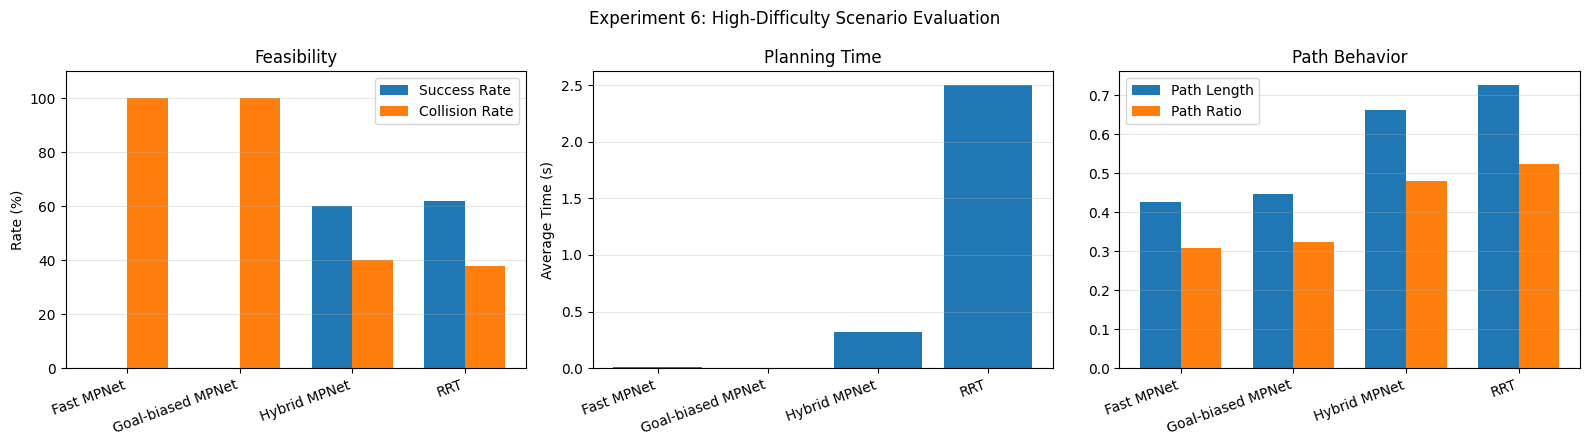

Saved: /content/drive/MyDrive/experiment6_high_difficulty_evaluation.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

methods = experiment6_df["method"].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Success and collision
axes[0].bar(x - 0.18, experiment6_df["success_rate"], width=0.36, label="Success Rate")
axes[0].bar(x + 0.18, experiment6_df["collision_rate"], width=0.36, label="Collision Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 110)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# Time
axes[1].bar(x, experiment6_df["avg_time"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylabel("Average Time (s)")
axes[1].set_title("Planning Time")
axes[1].grid(axis="y", alpha=0.3)

# Path behavior
axes[2].bar(x - 0.18, experiment6_df["avg_path_length"], width=0.36, label="Path Length")
axes[2].bar(x + 0.18, experiment6_df["avg_ratio"], width=0.36, label="Path Ratio")
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].set_title("Path Behavior")
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 6: High-Difficulty Scenario Evaluation")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment6_high_difficulty_evaluation.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


In [16]:
def evaluate_single_method_case_exp6(case, method_name):
    start = case["start"]
    goal = case["goal"]
    obs_xy = case["obs_xy"]
    obs_code = case["obs_code"]
    expert_path = case["expert_path"]

    if method_name == "Fast MPNet":
        path = generate_fast_mpnet_path(start, goal, obs_code)

    elif method_name == "Goal-biased MPNet":
        path = generate_goal_biased_mpnet_path(start, goal, obs_code)

    elif method_name == "Hybrid MPNet":
        path = generate_hybrid_for_exp6(start, goal, obs_code, obs_xy)

    elif method_name == "RRT":
        path = generate_rrt_path(start, goal, obs_xy)

    else:
        raise ValueError(method_name)

    metrics = evaluate_path(path, goal, obs_xy, expert_path)

    return path, metrics


def find_high_difficulty_qualitative_case(cases, max_candidates=10):
    candidates = []

    for case in cases:
        paths = {}
        metrics = {}

        for method in ["Fast MPNet", "Goal-biased MPNet", "Hybrid MPNet", "RRT"]:
            path, m = evaluate_single_method_case_exp6(case, method)
            paths[method] = path
            metrics[method] = m

        fast_bad = (not metrics["Fast MPNet"]["success"]) or metrics["Fast MPNet"]["collision"]
        goal_bad = (not metrics["Goal-biased MPNet"]["success"]) or metrics["Goal-biased MPNet"]["collision"]
        hybrid_good = metrics["Hybrid MPNet"]["success"] and (not metrics["Hybrid MPNet"]["collision"])
        rrt_good = metrics["RRT"]["success"] and (not metrics["RRT"]["collision"])

        if fast_bad and goal_bad and hybrid_good and rrt_good:
            candidates.append({
                "case": case,
                "paths": paths,
                "metrics": metrics,
                "score": case.get("difficulty_score", 0.0),
            })

            print(
                "candidate:",
                "env", case["env_id"],
                "case", case["case_id"],
                "score", round(case.get("difficulty_score", 0.0), 3),
                "detour", round(case.get("detour_ratio", 0.0), 3),
                "density", round(case.get("obstacle_density", 0.0), 3),
                "| Fast collision:", metrics["Fast MPNet"]["collision"],
                "| Goal collision:", metrics["Goal-biased MPNet"]["collision"],
                "| Hybrid success:", metrics["Hybrid MPNet"]["success"],
                "| RRT success:", metrics["RRT"]["success"],
            )

            if len(candidates) >= max_candidates:
                break

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    return candidates


exp6_qual_candidates = find_high_difficulty_qualitative_case(
    high_difficulty_cases,
    max_candidates=10
)

print("num candidates:", len(exp6_qual_candidates))

best_exp6 = exp6_qual_candidates[0]

print("Best high-difficulty qualitative case:")
print("env:", best_exp6["case"]["env_id"])
print("case:", best_exp6["case"]["case_id"])
print("difficulty score:", best_exp6["case"]["difficulty_score"])
print("detour ratio:", best_exp6["case"]["detour_ratio"])
print("obstacle density:", best_exp6["case"]["obstacle_density"])

for method, m in best_exp6["metrics"].items():
    print(method, m)


candidate: env 11 case 183 score 5.518 detour 4.768 density 0.15 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 12 case 191 score 5.419 detour 4.672 density 0.149 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 19 case 213 score 5.256 detour 4.267 density 0.198 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 18 case 138 score 5.137 detour 4.572 density 0.113 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 15 case 32 score 5.065 detour 2.876 density 0.438 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 17 case 269 score 4.985 detour 4.667 density 0.064 | Fast collision: True | Goal collision: True | Hybrid success: True | RRT success: True
candidate: env 2 case 99 score 4.884 detour 3.573 density 0.262 | Fast c

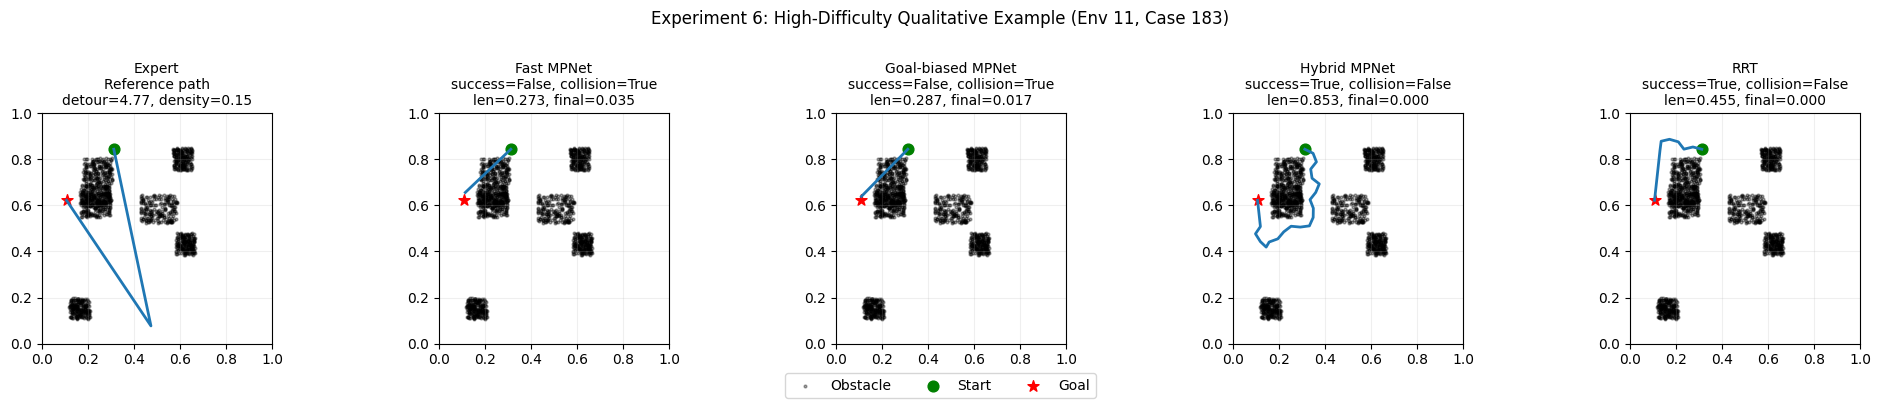

Saved: /content/drive/MyDrive/experiment6_high_difficulty_qualitative_example.png


In [17]:
def plot_high_difficulty_case(candidate, save_path):
    case = candidate["case"]
    paths = candidate["paths"]
    metrics = candidate["metrics"]

    obs_xy = case["obs_xy"]
    expert_path = case["expert_path"]
    start = case["start"]
    goal = case["goal"]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    plot_items = [
        ("Expert", expert_path, None),
        ("Fast MPNet", paths["Fast MPNet"], metrics["Fast MPNet"]),
        ("Goal-biased MPNet", paths["Goal-biased MPNet"], metrics["Goal-biased MPNet"]),
        ("Hybrid MPNet", paths["Hybrid MPNet"], metrics["Hybrid MPNet"]),
        ("RRT", paths["RRT"], metrics["RRT"]),
    ]

    for ax, (title, path, metric) in zip(axes, plot_items):
        ax.scatter(
            obs_xy[:, 0],
            obs_xy[:, 1],
            s=4,
            c="black",
            alpha=0.35,
            label="Obstacle"
        )

        path = np.asarray(path)
        ax.plot(path[:, 0], path[:, 1], linewidth=2)

        ax.scatter(start[0], start[1], c="green", s=60, marker="o", label="Start")
        ax.scatter(goal[0], goal[1], c="red", s=70, marker="*", label="Goal")

        if metric is None:
            subtitle = (
                f"Reference path\n"
                f"detour={case['detour_ratio']:.2f}, "
                f"density={case['obstacle_density']:.2f}"
            )
        else:
            subtitle = (
                f"success={metric['success']}, "
                f"collision={metric['collision']}\n"
                f"len={metric['path_length']:.3f}, "
                f"final={metric['final_dist']:.3f}"
            )

        ax.set_title(f"{title}\n{subtitle}", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3)

    plt.suptitle(
        f"Experiment 6: High-Difficulty Qualitative Example "
        f"(Env {case['env_id']}, Case {case['case_id']})"
    )

    plt.tight_layout(rect=[0, 0.10, 1, 0.92])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


plot_high_difficulty_case(
    best_exp6,
    "/content/drive/MyDrive/experiment6_high_difficulty_qualitative_example.png"
)


In [18]:
def sample_rect_obstacle(xmin, xmax, ymin, ymax, n):
    xs = np.random.uniform(xmin, xmax, size=n)
    ys = np.random.uniform(ymin, ymax, size=n)
    return np.stack([xs, ys], axis=1).astype(np.float32)


def make_narrow_passage_env():
    obstacles = []

    # Left wall block
    obstacles.append(sample_rect_obstacle(0.35, 0.45, 0.00, 0.45, 700))

    # Right wall block
    obstacles.append(sample_rect_obstacle(0.55, 0.65, 0.55, 1.00, 700))

    # Middle blocks forcing detour
    obstacles.append(sample_rect_obstacle(0.35, 0.65, 0.45, 0.52, 500))
    obstacles.append(sample_rect_obstacle(0.35, 0.65, 0.58, 0.65, 500))

    obs_xy = np.concatenate(obstacles, axis=0)

    # Keep same input size as original obstacle cloud if needed
    # Encoder expects flattened obstacle cloud length similar to original obc*.dat.
    return obs_xy.astype(np.float32)


In [19]:
obs_test = load_obs_xy(1)
print(obs_test.shape)


(1400, 2)


In [20]:
def normalize_obstacle_count(obs_xy, target_n=1400):
    obs_xy = np.asarray(obs_xy, dtype=np.float32)

    if len(obs_xy) > target_n:
        idx = np.random.choice(len(obs_xy), target_n, replace=False)
        return obs_xy[idx]

    if len(obs_xy) < target_n:
        idx = np.random.choice(len(obs_xy), target_n - len(obs_xy), replace=True)
        return np.vstack([obs_xy, obs_xy[idx]])

    return obs_xy


In [21]:
target_n = load_obs_xy(1).shape[0]
obs_xy = normalize_obstacle_count(make_narrow_passage_env(), target_n)
obs_code = get_obs_code(obs_xy)
print(obs_xy.shape, obs_code.shape)


(1400, 2) torch.Size([28])


In [22]:
def make_narrow_passage_cases(num_cases=20):
    target_n = load_obs_xy(1).shape[0]
    obs_xy = normalize_obstacle_count(make_narrow_passage_env(), target_n)
    obs_code = get_obs_code(obs_xy)

    cases = []

    for i in range(num_cases):
        start = np.array([
            np.random.uniform(0.08, 0.22),
            np.random.uniform(0.08, 0.25)
        ], dtype=np.float32)

        goal = np.array([
            np.random.uniform(0.78, 0.92),
            np.random.uniform(0.75, 0.92)
        ], dtype=np.float32)

        cases.append({
            "env_id": "designed_narrow_passage",
            "case_id": i,
            "start": start,
            "goal": goal,
            "obs_xy": obs_xy,
            "obs_code": obs_code,
            "expert_path": None,
        })

    return cases


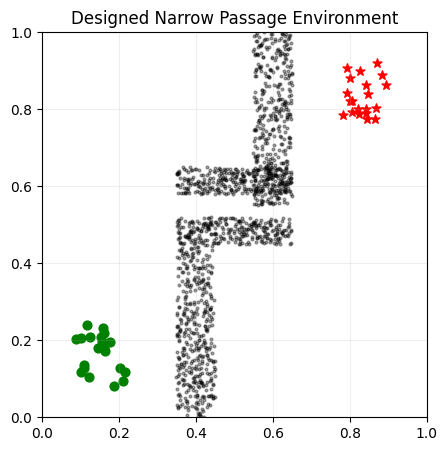

In [23]:
designed_cases = make_narrow_passage_cases(num_cases=20)

case0 = designed_cases[0]
obs_xy = case0["obs_xy"]

plt.figure(figsize=(5, 5))
plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=4, c="black", alpha=0.35)

for c in designed_cases:
    start = c["start"]
    goal = c["goal"]
    plt.scatter(start[0], start[1], c="green", s=40)
    plt.scatter(goal[0], goal[1], c="red", s=45, marker="*")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.2)
plt.title("Designed Narrow Passage Environment")
plt.show()


In [24]:
def evaluate_method_on_cases(cases, method_name):
    metrics_all = []

    for case in cases:
        start = case["start"]
        goal = case["goal"]
        obs_xy = case["obs_xy"]
        obs_code = case["obs_code"]
        expert_path = case.get("expert_path", None)

        t0 = time.time()

        if method_name == "Fast MPNet":
            path = generate_fast_mpnet_path(start, goal, obs_code)

        elif method_name == "Goal-biased MPNet":
            path = generate_goal_biased_mpnet_path(start, goal, obs_code)

        elif method_name == "Hybrid MPNet":
            path = generate_hybrid_for_exp6(start, goal, obs_code, obs_xy)

        elif method_name == "RRT":
            path = generate_rrt_path(start, goal, obs_xy)

        else:
            raise ValueError(method_name)

        elapsed = time.time() - t0

        metrics = evaluate_path(path, goal, obs_xy, expert_path)
        metrics["time"] = elapsed
        metrics_all.append(metrics)

    ratios = [m["ratio"] for m in metrics_all if not np.isnan(m["ratio"])]

    return {
        "method": method_name,
        "total": len(cases),
        "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
        "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
        "avg_time": float(np.mean([m["time"] for m in metrics_all])),
        "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
        "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
        "avg_ratio": float(np.mean(ratios)) if len(ratios) > 0 else np.nan,
    }


In [25]:
def evaluate_methods_on_designed_cases(cases):
    methods = [
        "Fast MPNet",
        "Goal-biased MPNet",
        "Hybrid MPNet",
        "RRT"
    ]

    rows = []

    for method in methods:
        row = evaluate_method_on_cases(cases, method)
        row["split"] = "Designed Narrow Passage"
        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

designed_df = evaluate_methods_on_designed_cases(designed_cases)

display(designed_df)

designed_df.to_csv(
    "/content/drive/MyDrive/experiment6_designed_narrow_passage_results.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_results.csv")


{'method': 'Fast MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0017243146896362305, 'avg_path_length': 0.8800647139549256, 'avg_final_dist': 0.07712955623865128, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Goal-biased MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.001252293586730957, 'avg_path_length': 0.914234659075737, 'avg_final_dist': 0.04250239171087742, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Hybrid MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.7243396043777466, 'avg_path_length': 0.8800647139549256, 'avg_final_dist': 0.07712955623865128, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'RRT', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 7.192780029773712, 'avg_path_length': 0.9566123753786087, 

,method,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio,split
0,Fast MPNet,20,0.0,100.0,0.001724,0.880065,0.077130,NaN,Designed Narrow Passage
1,Goal-biased MPNet,20,0.0,100.0,0.001252,0.914235,0.042502,NaN,Designed Narrow Passage
2,Hybrid MPNet,20,0.0,100.0,0.724340,0.880065,0.077130,NaN,Designed Narrow Passage
3,RRT,20,0.0,100.0,7.192780,0.956612,0.000000,NaN,Designed Narrow Passage


Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_results.csv


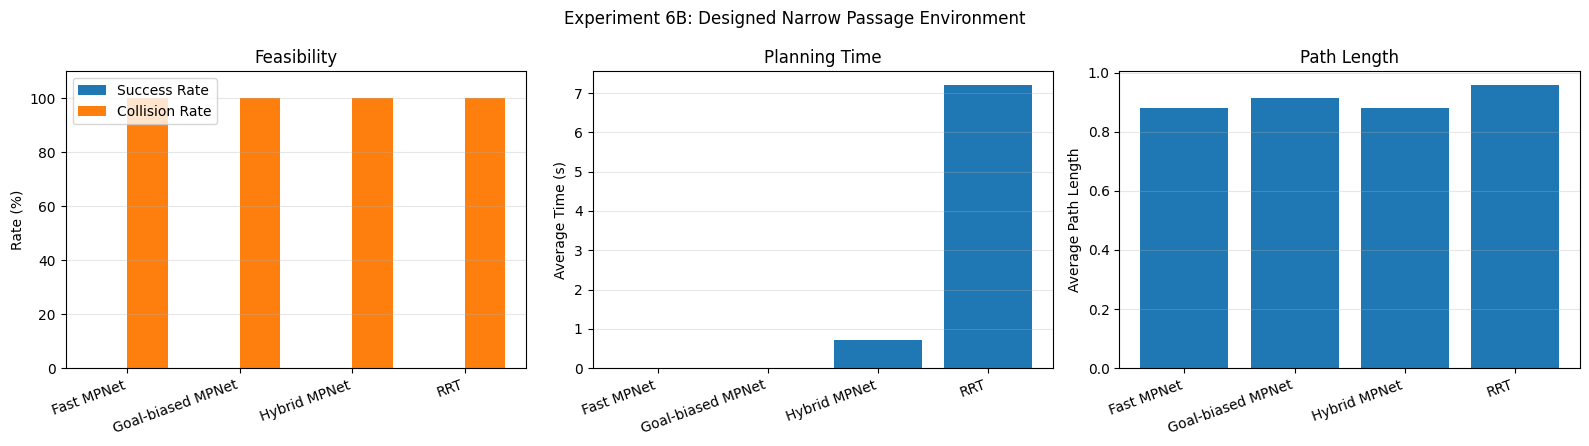

Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_results.png


In [26]:
methods = designed_df["method"].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(x - 0.18, designed_df["success_rate"], width=0.36, label="Success Rate")
axes[0].bar(x + 0.18, designed_df["collision_rate"], width=0.36, label="Collision Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 110)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(x, designed_df["avg_time"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylabel("Average Time (s)")
axes[1].set_title("Planning Time")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, designed_df["avg_path_length"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].set_ylabel("Average Path Length")
axes[2].set_title("Path Length")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 6B: Designed Narrow Passage Environment")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment6_designed_narrow_passage_results.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


In [27]:
def make_narrow_passage_env_v2():
    obstacles = []

    # Vertical blocks create side barriers but leave open regions.
    obstacles.append(sample_rect_obstacle(0.35, 0.45, 0.00, 0.40, 450))
    obstacles.append(sample_rect_obstacle(0.55, 0.65, 0.60, 1.00, 450))

    # Horizontal blocks create a narrow but feasible middle passage.
    obstacles.append(sample_rect_obstacle(0.32, 0.68, 0.40, 0.48, 350))
    obstacles.append(sample_rect_obstacle(0.32, 0.68, 0.64, 0.72, 350))

    # Small clutter blocks away from the main passage.
    obstacles.append(sample_rect_obstacle(0.15, 0.25, 0.55, 0.70, 150))
    obstacles.append(sample_rect_obstacle(0.72, 0.84, 0.30, 0.42, 150))

    obs_xy = np.concatenate(obstacles, axis=0)
    return obs_xy.astype(np.float32)


def make_narrow_passage_cases_v2(num_cases=20):
    target_n = load_obs_xy(1).shape[0]
    obs_xy = normalize_obstacle_count(make_narrow_passage_env_v2(), target_n)
    obs_code = get_obs_code(obs_xy)

    cases = []

    for i in range(num_cases):
        start = np.array([
            np.random.uniform(0.08, 0.22),
            np.random.uniform(0.08, 0.25)
        ], dtype=np.float32)

        goal = np.array([
            np.random.uniform(0.78, 0.92),
            np.random.uniform(0.75, 0.92)
        ], dtype=np.float32)

        cases.append({
            "env_id": "designed_narrow_passage_v2",
            "case_id": i,
            "start": start,
            "goal": goal,
            "obs_xy": obs_xy,
            "obs_code": obs_code,
            "expert_path": None,
        })

    return cases


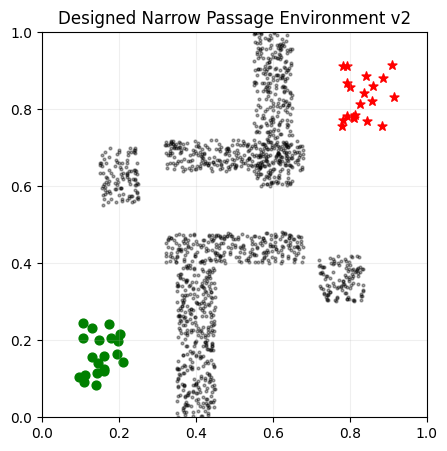

In [28]:
designed_cases_v2 = make_narrow_passage_cases_v2(num_cases=20)

case0 = designed_cases_v2[0]
obs_xy = case0["obs_xy"]

plt.figure(figsize=(5, 5))
plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=4, c="black", alpha=0.35)

for c in designed_cases_v2:
    start = c["start"]
    goal = c["goal"]
    plt.scatter(start[0], start[1], c="green", s=40)
    plt.scatter(goal[0], goal[1], c="red", s=45, marker="*")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.2)
plt.title("Designed Narrow Passage Environment v2")
plt.show()


In [29]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

designed_df_v2 = evaluate_methods_on_designed_cases(designed_cases_v2)

display(designed_df_v2)

designed_df_v2.to_csv(
    "/content/drive/MyDrive/experiment6_designed_narrow_passage_v2_results.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_v2_results.csv")


{'method': 'Fast MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.008910119533538818, 'avg_path_length': 0.8819970220327378, 'avg_final_dist': 0.07319914530962705, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Goal-biased MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0012040019035339355, 'avg_path_length': 0.914160618185997, 'avg_final_dist': 0.04048046711832285, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Hybrid MPNet', 'total': 20, 'success_rate': np.float64(90.0), 'collision_rate': np.float64(10.0), 'avg_time': 0.21781312227249144, 'avg_path_length': 1.2788039445877075, 'avg_final_dist': 0.006832650862634182, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'RRT', 'total': 20, 'success_rate': np.float64(100.0), 'collision_rate': np.float64(0.0), 'avg_time': 0.1563328266143799, 'avg_path_length': 1.278410276770591

,method,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio,split
0,Fast MPNet,20,0.0,100.0,0.008910,0.881997,0.073199,NaN,Designed Narrow Passage
1,Goal-biased MPNet,20,0.0,100.0,0.001204,0.914161,0.040480,NaN,Designed Narrow Passage
2,Hybrid MPNet,20,90.0,10.0,0.217813,1.278804,0.006833,NaN,Designed Narrow Passage
3,RRT,20,100.0,0.0,0.156333,1.278410,0.000000,NaN,Designed Narrow Passage


Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_v2_results.csv


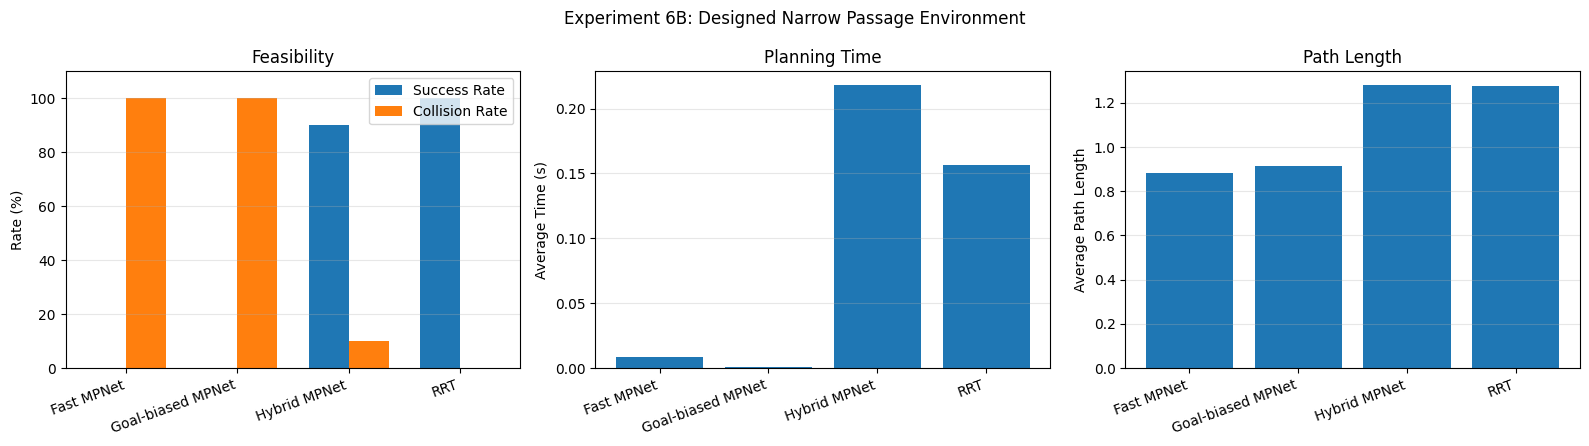

Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_final.png


In [30]:
designed_df_final = designed_df_v2.copy()

methods = designed_df_final["method"].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(x - 0.18, designed_df_final["success_rate"], width=0.36, label="Success Rate")
axes[0].bar(x + 0.18, designed_df_final["collision_rate"], width=0.36, label="Collision Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 110)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(x, designed_df_final["avg_time"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylabel("Average Time (s)")
axes[1].set_title("Planning Time")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, designed_df_final["avg_path_length"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].set_ylabel("Average Path Length")
axes[2].set_title("Path Length")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 6B: Designed Narrow Passage Environment")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment6_designed_narrow_passage_final.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


In [31]:
def find_designed_qualitative_case(cases):
    candidates = []

    for case in cases:
        paths = {}
        metrics = {}

        for method in ["Fast MPNet", "Goal-biased MPNet", "Hybrid MPNet", "RRT"]:
            path, m = evaluate_single_method_case_exp6(case, method)
            paths[method] = path
            metrics[method] = m

        if (
            metrics["Fast MPNet"]["collision"]
            and metrics["Goal-biased MPNet"]["collision"]
            and metrics["Hybrid MPNet"]["success"]
            and not metrics["Hybrid MPNet"]["collision"]
            and metrics["RRT"]["success"]
            and not metrics["RRT"]["collision"]
        ):
            candidates.append({
                "case": case,
                "paths": paths,
                "metrics": metrics,
            })

    print("num candidates:", len(candidates))
    return candidates[0]


best_designed = find_designed_qualitative_case(designed_cases_v2)


num candidates: 19


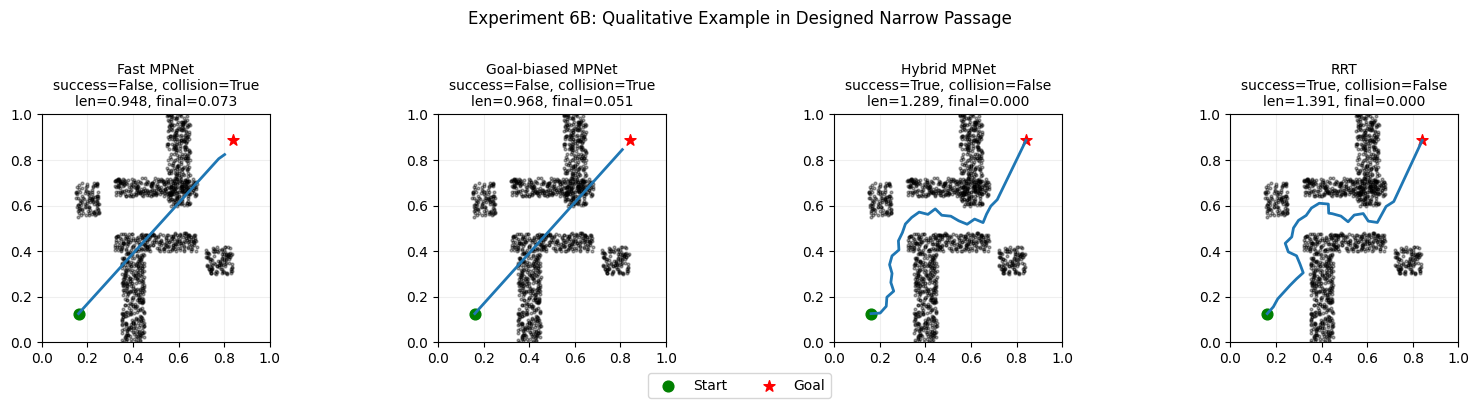

Saved: /content/drive/MyDrive/experiment6_designed_narrow_passage_qualitative.png


In [32]:
def plot_designed_case(candidate, save_path):
    case = candidate["case"]
    paths = candidate["paths"]
    metrics = candidate["metrics"]

    obs_xy = case["obs_xy"]
    start = case["start"]
    goal = case["goal"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    plot_items = [
        ("Fast MPNet", paths["Fast MPNet"], metrics["Fast MPNet"]),
        ("Goal-biased MPNet", paths["Goal-biased MPNet"], metrics["Goal-biased MPNet"]),
        ("Hybrid MPNet", paths["Hybrid MPNet"], metrics["Hybrid MPNet"]),
        ("RRT", paths["RRT"], metrics["RRT"]),
    ]

    for ax, (title, path, metric) in zip(axes, plot_items):
        ax.scatter(obs_xy[:, 0], obs_xy[:, 1], s=4, c="black", alpha=0.35)

        path = np.asarray(path)
        ax.plot(path[:, 0], path[:, 1], linewidth=2)

        ax.scatter(start[0], start[1], c="green", s=60, marker="o", label="Start")
        ax.scatter(goal[0], goal[1], c="red", s=70, marker="*", label="Goal")

        subtitle = (
            f"success={metric['success']}, collision={metric['collision']}\n"
            f"len={metric['path_length']:.3f}, final={metric['final_dist']:.3f}"
        )

        ax.set_title(f"{title}\n{subtitle}", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2)

    plt.suptitle("Experiment 6B: Qualitative Example in Designed Narrow Passage")
    plt.tight_layout(rect=[0, 0.10, 1, 0.92])

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


plot_designed_case(
    best_designed,
    "/content/drive/MyDrive/experiment6_designed_narrow_passage_qualitative.png"
)


In [35]:
def sample_rect_obstacle(xmin, xmax, ymin, ymax, n):
    xs = np.random.uniform(xmin, xmax, size=n)
    ys = np.random.uniform(ymin, ymax, size=n)
    return np.stack([xs, ys], axis=1).astype(np.float32)


def make_two_gate_barrier_env():
    obstacles = []

    # A thick central vertical barrier, split into three parts.
    # Two gates are left open around y≈0.30 and y≈0.70.
    obstacles.append(sample_rect_obstacle(0.45, 0.56, 0.00, 0.22, 350))
    obstacles.append(sample_rect_obstacle(0.45, 0.56, 0.38, 0.62, 420))
    obstacles.append(sample_rect_obstacle(0.45, 0.56, 0.78, 1.00, 350))

    # Additional blocks near the gates to make the passage nontrivial
    # while keeping it feasible.
    obstacles.append(sample_rect_obstacle(0.25, 0.38, 0.26, 0.38, 180))
    obstacles.append(sample_rect_obstacle(0.63, 0.76, 0.62, 0.74, 180))

    # Small clutter away from start/goal.
    obstacles.append(sample_rect_obstacle(0.22, 0.32, 0.66, 0.78, 120))
    obstacles.append(sample_rect_obstacle(0.70, 0.82, 0.22, 0.34, 120))

    obs_xy = np.concatenate(obstacles, axis=0)
    return obs_xy.astype(np.float32)


def make_two_gate_barrier_cases(num_cases=20):
    target_n = load_obs_xy(1).shape[0]
    obs_xy = normalize_obstacle_count(make_two_gate_barrier_env(), target_n)
    obs_code = get_obs_code(obs_xy)

    cases = []

    for i in range(num_cases):
        # Start on lower-left side.
        start = np.array([
            np.random.uniform(0.08, 0.20),
            np.random.uniform(0.08, 0.22)
        ], dtype=np.float32)

        # Goal on upper-right side.
        goal = np.array([
            np.random.uniform(0.80, 0.92),
            np.random.uniform(0.78, 0.92)
        ], dtype=np.float32)

        cases.append({
            "env_id": "designed_two_gate_barrier",
            "case_id": i,
            "start": start,
            "goal": goal,
            "obs_xy": obs_xy,
            "obs_code": obs_code,
            "expert_path": None,
        })

    return cases


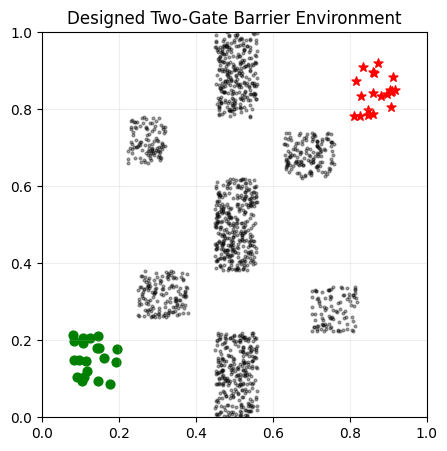

In [36]:
two_gate_cases = make_two_gate_barrier_cases(num_cases=20)

case0 = two_gate_cases[0]
obs_xy = case0["obs_xy"]

plt.figure(figsize=(5, 5))
plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=4, c="black", alpha=0.35)

for c in two_gate_cases:
    start = c["start"]
    goal = c["goal"]
    plt.scatter(start[0], start[1], c="green", s=40)
    plt.scatter(goal[0], goal[1], c="red", s=45, marker="*")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.2)
plt.title("Designed Two-Gate Barrier Environment")
plt.show()


In [37]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

two_gate_df = evaluate_methods_on_designed_cases(two_gate_cases)

display(two_gate_df)

two_gate_df.to_csv(
    "/content/drive/MyDrive/experiment6_two_gate_barrier_results.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/experiment6_two_gate_barrier_results.csv")


{'method': 'Fast MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0019266366958618163, 'avg_path_length': 0.935278907418251, 'avg_final_dist': 0.07809003200381995, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Goal-biased MPNet', 'total': 20, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0012796401977539062, 'avg_path_length': 0.9654330313205719, 'avg_final_dist': 0.0469177670776844, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'Hybrid MPNet', 'total': 20, 'success_rate': np.float64(100.0), 'collision_rate': np.float64(0.0), 'avg_time': 0.17728188037872314, 'avg_path_length': 1.2493245363235475, 'avg_final_dist': 0.0, 'avg_ratio': nan, 'split': 'Designed Narrow Passage'}
{'method': 'RRT', 'total': 20, 'success_rate': np.float64(100.0), 'collision_rate': np.float64(0.0), 'avg_time': 0.22758225202560425, 'avg_path_length': 1.2516803085803985, 'avg_final_di

,method,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio,split
0,Fast MPNet,20,0.0,100.0,0.001927,0.935279,0.078090,NaN,Designed Narrow Passage
1,Goal-biased MPNet,20,0.0,100.0,0.001280,0.965433,0.046918,NaN,Designed Narrow Passage
2,Hybrid MPNet,20,100.0,0.0,0.177282,1.249325,0.000000,NaN,Designed Narrow Passage
3,RRT,20,100.0,0.0,0.227582,1.251680,0.000000,NaN,Designed Narrow Passage


Saved: /content/drive/MyDrive/experiment6_two_gate_barrier_results.csv


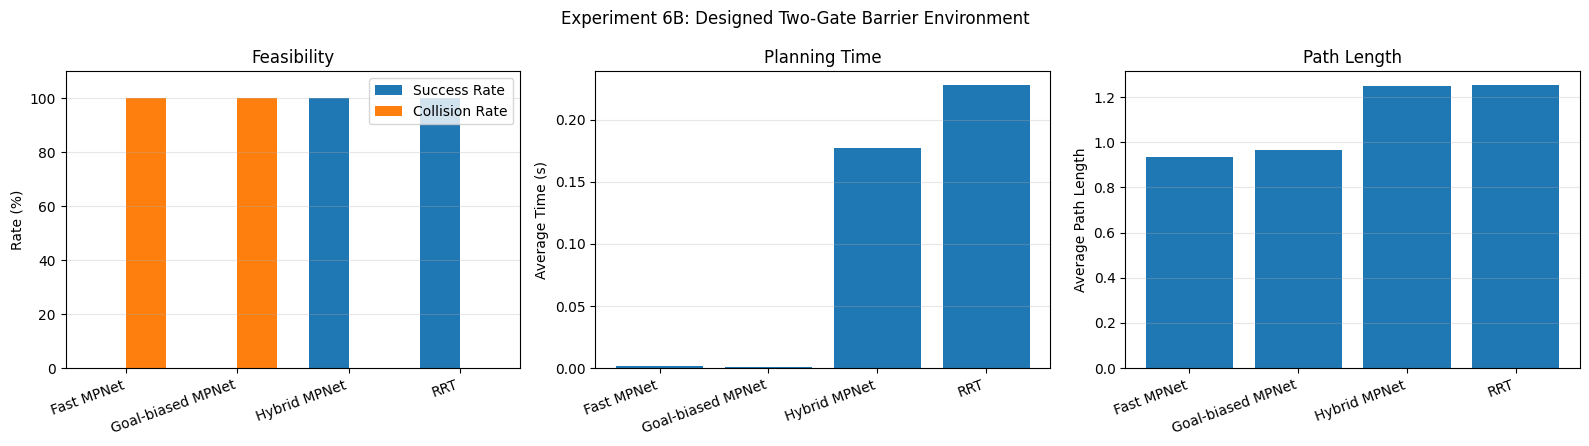

Saved: /content/drive/MyDrive/experiment6_two_gate_barrier_results.png


In [38]:
two_gate_df_final = two_gate_df.copy()
two_gate_df_final["split"] = "Designed Two-Gate Barrier"

methods = two_gate_df_final["method"].tolist()
x = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(x - 0.18, two_gate_df_final["success_rate"], width=0.36, label="Success Rate")
axes[0].bar(x + 0.18, two_gate_df_final["collision_rate"], width=0.36, label="Collision Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 110)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(x, two_gate_df_final["avg_time"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylabel("Average Time (s)")
axes[1].set_title("Planning Time")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, two_gate_df_final["avg_path_length"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].set_ylabel("Average Path Length")
axes[2].set_title("Path Length")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 6B: Designed Two-Gate Barrier Environment")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment6_two_gate_barrier_results.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

two_gate_df_final.to_csv(
    "/content/drive/MyDrive/experiment6_two_gate_barrier_results.csv",
    index=False
)

print("Saved:", save_path)


In [39]:
def plot_two_gate_case(candidate, save_path):
    case = candidate["case"]
    paths = candidate["paths"]
    metrics = candidate["metrics"]

    obs_xy = case["obs_xy"]
    start = case["start"]
    goal = case["goal"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    plot_items = [
        ("Fast MPNet", paths["Fast MPNet"], metrics["Fast MPNet"]),
        ("Goal-biased MPNet", paths["Goal-biased MPNet"], metrics["Goal-biased MPNet"]),
        ("Hybrid MPNet", paths["Hybrid MPNet"], metrics["Hybrid MPNet"]),
        ("RRT", paths["RRT"], metrics["RRT"]),
    ]

    for ax, (title, path, metric) in zip(axes, plot_items):
        ax.scatter(obs_xy[:, 0], obs_xy[:, 1], s=4, c="black", alpha=0.35)

        path = np.asarray(path)
        ax.plot(path[:, 0], path[:, 1], linewidth=2)

        ax.scatter(start[0], start[1], c="green", s=60, marker="o", label="Start")
        ax.scatter(goal[0], goal[1], c="red", s=70, marker="*", label="Goal")

        subtitle = (
            f"success={metric['success']}, collision={metric['collision']}\n"
            f"len={metric['path_length']:.3f}, final={metric['final_dist']:.3f}"
        )

        ax.set_title(f"{title}\n{subtitle}", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2)

    plt.suptitle("Experiment 6B: Qualitative Example in Designed Two-Gate Barrier")
    plt.tight_layout(rect=[0, 0.10, 1, 0.92])

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


In [41]:
best_two_gate = find_designed_qualitative_case(two_gate_cases)

print("Best two-gate case:")
print("env:", best_two_gate["case"]["env_id"])
print("case:", best_two_gate["case"]["case_id"])

for method, m in best_two_gate["metrics"].items():
    print(method, m)


num candidates: 20
Best two-gate case:
env: designed_two_gate_barrier
case: 0
Fast MPNet {'success': False, 'collision': True, 'final_dist': 0.08308953046798706, 'path_length': 0.8767135739326477, 'ratio': nan}
Goal-biased MPNet {'success': False, 'collision': True, 'final_dist': 0.04154478758573532, 'path_length': 0.9182219505310059, 'ratio': nan}
Hybrid MPNet {'success': True, 'collision': False, 'final_dist': 0.0, 'path_length': 1.1531744003295898, 'ratio': nan}
RRT {'success': True, 'collision': False, 'final_dist': 0.0, 'path_length': 1.2466378211975098, 'ratio': nan}


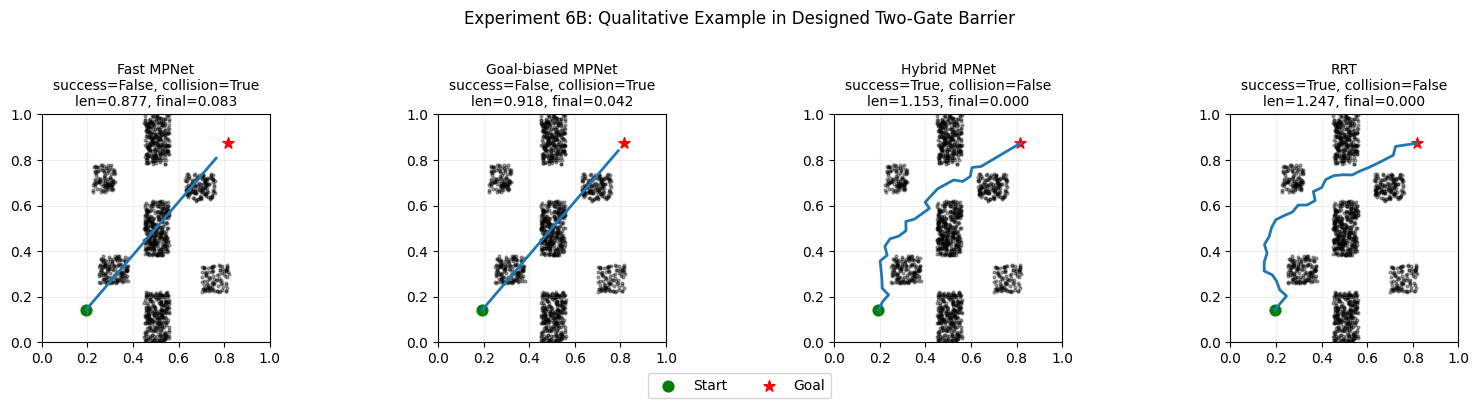

Saved: /content/drive/MyDrive/experiment6_two_gate_barrier_qualitative.png


In [42]:
plot_two_gate_case(
    best_two_gate,
    "/content/drive/MyDrive/experiment6_two_gate_barrier_qualitative.png"
)


In [43]:
pnet_trained = pnet

pnet_untrained = MLP(32, 2).to(device)
pnet_untrained.eval()

print("Trained and untrained MPNet models ready")


Trained and untrained MPNet models ready


In [44]:
def generate_mpnet_path_with_model(model, start, goal, obs_code, max_steps=150):
    current = torch.from_numpy(np.asarray(start, dtype=np.float32)).float().to(device)
    goal_t = torch.from_numpy(np.asarray(goal, dtype=np.float32)).float().to(device)

    if not isinstance(obs_code, torch.Tensor):
        obs_code = torch.from_numpy(np.asarray(obs_code, dtype=np.float32)).float().to(device)
    else:
        obs_code = obs_code.float().to(device)

    obs_code = obs_code.view(-1)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)
            next_state = model(inp).squeeze(0)

            path.append(next_state.detach().cpu().numpy())
            current = next_state

            if torch.norm(current - goal_t).item() <= GOAL_THRESHOLD:
                break

    return np.asarray(path, dtype=np.float32)


In [47]:
import os
import re
import numpy as np
import torch

DATASET_DIR = "/content/dataset"


def sorted_case_ids(env_id):
    folder = f"{DATASET_DIR}/e{env_id}"
    files = [
        f for f in os.listdir(folder)
        if re.match(r"path\d+\.dat$", f)
    ]
    return sorted(int(re.findall(r"\d+", f)[0]) for f in files)


def load_obs_xy(env_id):
    obs_file = f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat"
    obs = np.fromfile(obs_file)
    return obs.reshape(-1, 2).astype(np.float32)


def load_expert_path(env_id, case_id):
    path_file = f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
    path = np.fromfile(path_file)
    return path.reshape(-1, 2).astype(np.float32)


def get_obs_code(obs_xy):
    obs_flat = obs_xy.reshape(-1)
    obs_input = torch.from_numpy(obs_flat).float().unsqueeze(0).to(device)

    with torch.no_grad():
        return encoder(obs_input).squeeze(0)


def build_eval_cases(cases_per_env=50, env_ids=range(1, 15)):
    cases = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        ids = sorted_case_ids(env_id)[:cases_per_env]

        for case_id in ids:
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            cases.append({
                "env_id": env_id,
                "case_id": case_id,
                "start": expert_path[0],
                "goal": expert_path[-1],
                "obs_xy": obs_xy,
                "obs_code": obs_code,
                "expert_path": expert_path,
            })

    return cases


In [48]:
reference_cases = build_eval_cases(cases_per_env=50, env_ids=range(1, 15))
learning_cases = reference_cases

print("learning_cases:", len(learning_cases))


learning_cases: 700


In [51]:
pnet_trained = pnet

pnet_untrained = MLP(32, 2).to(device)
pnet_untrained.eval()

print("Models ready")


Models ready


In [52]:
def generate_mpnet_path_with_model(model, start, goal, obs_code, max_steps=150):
    current = torch.from_numpy(np.asarray(start, dtype=np.float32)).float().to(device)
    goal_t = torch.from_numpy(np.asarray(goal, dtype=np.float32)).float().to(device)

    if not isinstance(obs_code, torch.Tensor):
        obs_code = torch.from_numpy(np.asarray(obs_code, dtype=np.float32)).float().to(device)
    else:
        obs_code = obs_code.float().to(device)

    obs_code = obs_code.view(-1)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)
            next_state = model(inp).squeeze(0)

            path.append(next_state.detach().cpu().numpy())
            current = next_state

            if torch.norm(current - goal_t).item() <= GOAL_THRESHOLD:
                break

    return np.asarray(path, dtype=np.float32)


In [53]:
def evaluate_model_learning_behavior(cases, model, model_name):
    metrics_all = []

    for case in cases:
        start = case["start"]
        goal = case["goal"]
        obs_xy = case["obs_xy"]
        obs_code = case["obs_code"]
        expert_path = case["expert_path"]

        t0 = time.time()

        path = generate_mpnet_path_with_model(
            model=model,
            start=start,
            goal=goal,
            obs_code=obs_code,
            max_steps=150
        )

        elapsed = time.time() - t0

        metrics = evaluate_path(path, goal, obs_xy, expert_path)
        metrics["time"] = elapsed
        metrics_all.append(metrics)

    return {
        "model": model_name,
        "total": len(cases),
        "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
        "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
        "avg_time": float(np.mean([m["time"] for m in metrics_all])),
        "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
        "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
        "avg_ratio": float(np.nanmean([m["ratio"] for m in metrics_all])),
    }


learning_rows = []

learning_rows.append(
    evaluate_model_learning_behavior(
        learning_cases,
        pnet_trained,
        "Trained MPNet"
    )
)

learning_rows.append(
    evaluate_model_learning_behavior(
        learning_cases,
        pnet_untrained,
        "Untrained Network"
    )
)

learning_df = pd.DataFrame(learning_rows)

display(learning_df)

learning_df.to_csv(
    "/content/drive/MyDrive/learning_behavior_trained_vs_untrained.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/learning_behavior_trained_vs_untrained.csv")


,model,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio
0,Trained MPNet,700,41.0,56.857143,0.009853,0.475780,0.059891,0.791902
1,Untrained Network,700,0.0,46.428571,0.161408,0.807425,0.804848,2.329578


Saved: /content/drive/MyDrive/learning_behavior_trained_vs_untrained.csv


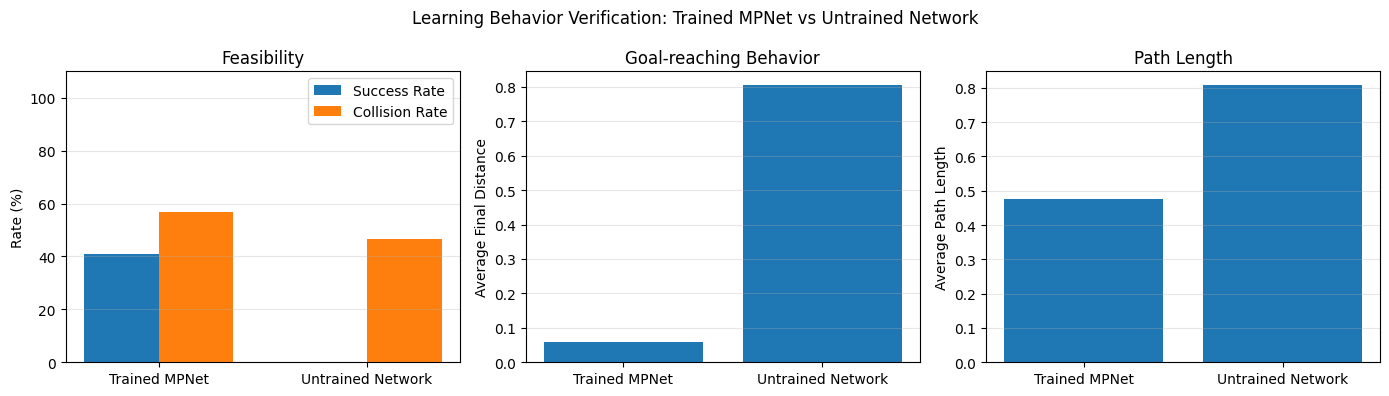

Saved: /content/drive/MyDrive/learning_behavior_trained_vs_untrained.png


In [54]:
models = learning_df["model"].tolist()
x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(x - 0.18, learning_df["success_rate"], width=0.36, label="Success Rate")
axes[0].bar(x + 0.18, learning_df["collision_rate"], width=0.36, label="Collision Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 110)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(x, learning_df["avg_final_dist"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("Average Final Distance")
axes[1].set_title("Goal-reaching Behavior")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, learning_df["avg_path_length"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylabel("Average Path Length")
axes[2].set_title("Path Length")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Learning Behavior Verification: Trained MPNet vs Untrained Network")
plt.tight_layout()

save_path = "/content/drive/MyDrive/learning_behavior_trained_vs_untrained.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
